In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
sns.set_style("whitegrid")
df = pd.read_csv(r"C:\Users\Andrey\Documents\Faculdade\ProjetoIntegradorDados\projeto-integrador-netflix\dados\processed\netflix_clean.csv")

In [19]:
df_series = df[df['type'] == 'TV Show'].copy()

In [20]:
df_series['duration'].head()

1    2 Seasons
2     1 Season
3     1 Season
4    2 Seasons
5     1 Season
Name: duration, dtype: str

In [21]:
df_series['num_temporadas'] = (
    df_series['duration']
    .str.extract(r'(\d+)')   # extrai apenas números
    .astype(int)             # converte para inteiro
)

In [22]:
df_series['categoria_retencao'] = df_series['num_temporadas'].apply(
    lambda x: 'Temporada Única' if x == 1 else 'Séries Longevas'
)

In [23]:
contagem = df_series['categoria_retencao'].value_counts()

In [24]:
print(contagem)

categoria_retencao
Temporada Única    1793
Séries Longevas     883
Name: count, dtype: int64


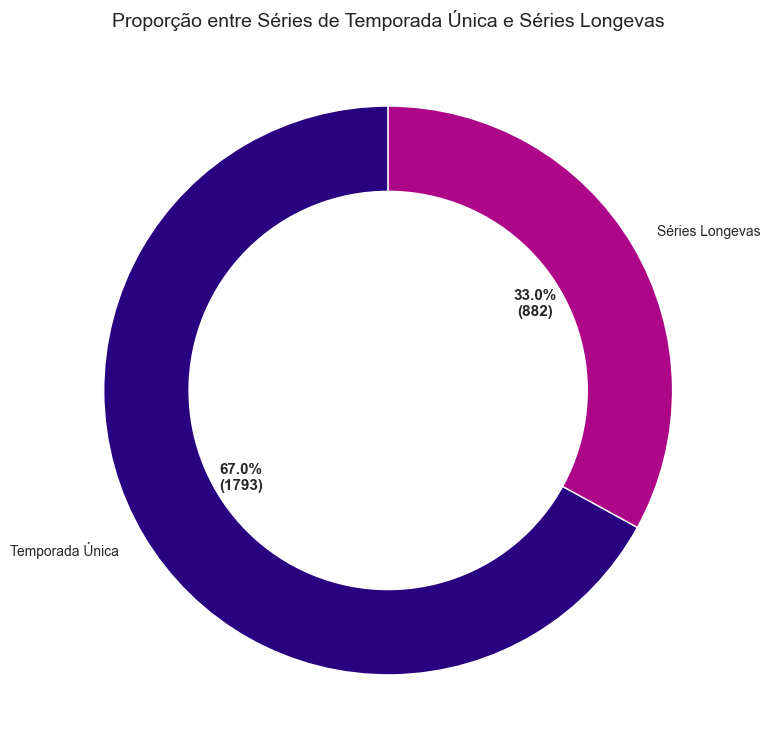

In [27]:
plt.figure(figsize=(8,8))

# Cores
cores = ["#280281", "#ad0689"]

# Gráfico de pizza
wedges, texts, autotexts = plt.pie(
    contagem,
    labels=contagem.index,
    autopct=lambda p: f'{p:.1f}%\n({int(p * contagem.sum() / 100)})',
    startangle=90,
    colors=cores,
    wedgeprops={'edgecolor': 'white'}
)

centro = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro)

# Título
plt.title('Proporção entre Séries de Temporada Única e Séries Longevas', fontsize=14)

# Texto
plt.setp(autotexts, size=11, weight="bold")

# Gráfico
plt.tight_layout()
plt.show()